In [1]:
import importlib
import re
import time
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import umap
import torch
import subprocess
import sys
import hdbscan
from bertopic import BERTopic
from joblib import Parallel, delayed
from langdetect import detect
from scipy.stats import chi2_contingency
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from tqdm import tqdm


import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

#importlib.reload(src.fct_data)
import src
from src.fct_data import raw_data_cleaning, clean_prof
from src.fct_nlp import split_text_chunk
importlib.reload(src.fct_data)


model_name = "fr_core_news_sm"
try:
    nlp = spacy.load(model_name)
except OSError:
    print(f"Installation de {model_name}...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", model_name])
    nlp = spacy.load(model_name)

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Installation de fr_core_news_sm...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 39.5 MB/s  0:00:00m0:00:010:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')


## Extraction des données



Traitement pour les 5 années disponibles sur le `gitlab` 

In [2]:
#on récupère un df avec métadonnées + texte nettoyé des stopwords
meta_et_texts = raw_data_cleaning("data/archelect_search.zip","data/text_files")

/home/onyxia/work/NLP_3A/src/fct_data.py:17: DtypeWarning: Columns (8,9,10,12,28,29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  metadonnees = pd.read_csv("data/archelect_search.zip", compression="zip")


Traitement de data/text_files/1988/legislatives.zip
Traitement de data/text_files/1981/legislatives.zip
Traitement de data/text_files/1973/legislatives.zip
Traitement de data/text_files/1978/legislatives.zip
Traitement de data/text_files/1993/presidentielle.zip
Traitement de data/text_files/1993/legislatives.zip
Nombre total de documents extraits : 21697


In [3]:
print(meta_et_texts.shape)
print(meta_et_texts.columns)

(21697, 45)
Index(['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour',
       'cote', 'departement', 'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations', 'text',
       'zip_path', 'annee'],
      dtype='obj

In [4]:
meta_et_texts['contexte-election'].value_counts()

contexte-election
législatives    21167
Name: count, dtype: int64

We keep only the legislative elections.

In [5]:
meta_et_texts = meta_et_texts[meta_et_texts['contexte-election'] == 'législatives']

In [6]:
meta_et_texts.head()


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations,text,zip_path,annee
0,EL174_L_1988_06_001_02_2_PF_02,1988-06-12,Ve République;Assemblée Nationale;Élections lé...,"Élections législatives de 1988, Ain - 01, circ...",législatives,2.0,EL174,01,Ain,01 - Ain,...,conseiller général,non mentionné,non mentionné,non mentionné,Union pour la démocratie française;Rassembleme...,Union du rassemblement et du centre,non,LIBERTÉ ÉGALITÉ FRATERNITÉ RÉPUBLIQUE FRANÇAIS...,data/text_files/1988/legislatives.zip,1988.0
1,EL175_L_1988_06_045_01_1_PF_01,1988-06-05,Assemblée Nationale;France;Élections législati...,"Élections législatives de 1988, Loiret - 45, c...",législatives,1.0,EL175,45,Loiret,45 - Loiret,...,conseiller municipal;conseiller régional,non mentionné,culture;syndicat;local,non mentionné,non mentionné,Majorité présidentielle pour la France unie,non,LA FRANCE UNIE avec Jean-Pierre SUEUR DÉPUTÉ D...,data/text_files/1988/legislatives.zip,1988.0
2,EL177_L_1988_06_094_01_1_PF_01,1988-06-05,Assemblée Nationale;France;Ve République;Élect...,"Élections législatives de 1988, Val-de-Marne -...",législatives,1.0,EL177,94,Val-de-Marne,94 - Val-de-Marne,...,non mentionné,non mentionné,non mentionné,non mentionné,Centre national des indépendants et paysans;Ra...,Union du rassemblement et du centre,non,ÉLECTIONS LÉGISLATIVES DES 5 ET 12 JUIN 1988 1...,data/text_files/1988/legislatives.zip,1988.0
3,EL177_L_1988_06_075_15_1_PF_04,1988-06-05,Ve République;France;Élections législatives;As...,"Élections législatives de 1988, Paris - 75, ci...",législatives,1.0,EL177,75,Paris,75 - Paris (Seine),...,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non,Élections Législatives Maurice Mercante présen...,data/text_files/1988/legislatives.zip,1988.0
4,EL175_L_1988_06_033_05_1_PF_03,1988-06-05,France;Élections législatives;Assemblée Nation...,"Élections législatives de 1988, Gironde - 33, ...",législatives,1.0,EL175,33,Gironde,33 - Gironde,...,non mentionné,non mentionné,politique,non mentionné,Front national,Liste entente populaire et nationale,non,Maintenant la force d'avenir c'est le Front Na...,data/text_files/1988/legislatives.zip,1988.0


We do some final cleaning to make sure there will be not error when running our methods

In [7]:
meta_et_texts = meta_et_texts.dropna(subset=['text']) #remove lines without texts
meta_et_texts = meta_et_texts[meta_et_texts['text'].str.strip() != ''] #same for lines with empty text
meta_et_texts['annee'] = pd.to_datetime(meta_et_texts['date'], errors='coerce').dt.year

meta_et_texts = meta_et_texts.reset_index(drop=True)
df = meta_et_texts.copy()

In [8]:
#df = df[df["annee"].isin([1981, 1988, 1993])].copy()
print(df.shape)
df.head()

(21167, 45)


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations,text,zip_path,annee
0,EL174_L_1988_06_001_02_2_PF_02,1988-06-12,Ve République;Assemblée Nationale;Élections lé...,"Élections législatives de 1988, Ain - 01, circ...",législatives,2.0,EL174,01,Ain,01 - Ain,...,conseiller général,non mentionné,non mentionné,non mentionné,Union pour la démocratie française;Rassembleme...,Union du rassemblement et du centre,non,LIBERTÉ ÉGALITÉ FRATERNITÉ RÉPUBLIQUE FRANÇAIS...,data/text_files/1988/legislatives.zip,1988
1,EL175_L_1988_06_045_01_1_PF_01,1988-06-05,Assemblée Nationale;France;Élections législati...,"Élections législatives de 1988, Loiret - 45, c...",législatives,1.0,EL175,45,Loiret,45 - Loiret,...,conseiller municipal;conseiller régional,non mentionné,culture;syndicat;local,non mentionné,non mentionné,Majorité présidentielle pour la France unie,non,LA FRANCE UNIE avec Jean-Pierre SUEUR DÉPUTÉ D...,data/text_files/1988/legislatives.zip,1988
2,EL177_L_1988_06_094_01_1_PF_01,1988-06-05,Assemblée Nationale;France;Ve République;Élect...,"Élections législatives de 1988, Val-de-Marne -...",législatives,1.0,EL177,94,Val-de-Marne,94 - Val-de-Marne,...,non mentionné,non mentionné,non mentionné,non mentionné,Centre national des indépendants et paysans;Ra...,Union du rassemblement et du centre,non,ÉLECTIONS LÉGISLATIVES DES 5 ET 12 JUIN 1988 1...,data/text_files/1988/legislatives.zip,1988
3,EL177_L_1988_06_075_15_1_PF_04,1988-06-05,Ve République;France;Élections législatives;As...,"Élections législatives de 1988, Paris - 75, ci...",législatives,1.0,EL177,75,Paris,75 - Paris (Seine),...,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non,Élections Législatives Maurice Mercante présen...,data/text_files/1988/legislatives.zip,1988
4,EL175_L_1988_06_033_05_1_PF_03,1988-06-05,France;Élections législatives;Assemblée Nation...,"Élections législatives de 1988, Gironde - 33, ...",législatives,1.0,EL175,33,Gironde,33 - Gironde,...,non mentionné,non mentionné,politique,non mentionné,Front national,Liste entente populaire et nationale,non,Maintenant la force d'avenir c'est le Front Na...,data/text_files/1988/legislatives.zip,1988


## 0/ Some descriptive statistics

In [16]:
print(f"Nombre de professions différentes répertoriées : {meta_et_texts['titulaire-profession'].nunique()}")
print("")
print("Liste :")
print(meta_et_texts['titulaire-profession'].value_counts())

Nombre de professions différentes répertoriées : 3397

Liste :
titulaire-profession
non mentionné                                                                 9465
professeur                                                                     480
avocat                                                                         368
chef d'entreprise                                                              234
ingénieur                                                                      232
                                                                              ... 
chargé de mission inspection générale Ministre de l'Education nationale          1
gynécologue-accoucheur;directeur clinique                                        1
agrégée philosophie;maître de conférences Université                             1
attaché administration centrale Ministère des Postes et Télécommunications       1
chef de travaux;directeur ateliers collège enseignement technique                1
Nam

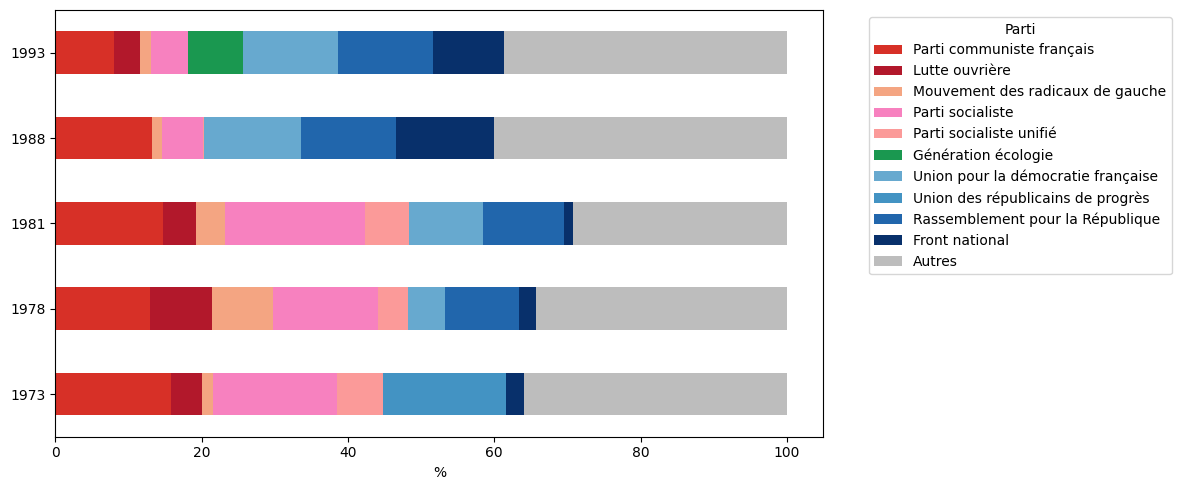

In [38]:
colors = {
    "Parti communiste français": "#d73027",      # rouge vif
    "Parti socialiste": "#f781bf",               # rose
    "Rassemblement pour la République": "#2166ac",  # bleu droite gaulliste
    "Union pour la démocratie française": "#67a9cf", # bleu clair (centre droit)
    "Front national": "#08306b",                 # bleu marine (droite radicale)
    "Lutte ouvrière": "#b2182b",                 # rouge foncé (extrême gauche)
    "Mouvement des radicaux de gauche": "#f4a582", # rose-orangée (centre gauche)
    "Parti socialiste unifié": "#fb9a99",        # rose clair
    "Union des républicains de progrès": "#4393c3", # bleu intermédiaire
    "Génération écologie": "#1a9850",            # vert
    "Autres": "#bdbdbd"                          # gris neutre
}

df = meta_et_texts.dropna(subset=['titulaire-soutien']).copy()
df['annee'] = pd.to_datetime(df['date']).dt.year


df['partis_list'] = df['titulaire-soutien'].str.split(';')
df['partis_list'] = df['partis_list'].apply(lambda x: [p.strip() for p in x])

df_exploded = df.explode('partis_list')
df_exploded = df_exploded[df_exploded['partis_list'] != 'non mentionné']

top10 = df_exploded['partis_list'].value_counts().head(10).index

#autre qui si aucun soutien d'un des 10 plus grand partis 
def filtrer_partis(partis):
    partis_top = [p for p in partis if p in top10]
    if len(partis_top) > 0:
        return partis_top 
    else:
        return ['Autres'] 

df['partis_filtres'] = df['partis_list'].apply(filtrer_partis)

df_final = df.explode('partis_filtres')

table = pd.crosstab(df_final['annee'], df_final['partis_filtres'])
table_pct = table.div(table.sum(axis=1), axis=0) * 100
table_pct = table_pct[top10.tolist() + ['Autres']]

#plot
ordre_politique = [
    "Parti communiste français", 
    "Lutte ouvrière", 
    "Mouvement des radicaux de gauche", 
    "Parti socialiste", 
    "Parti socialiste unifié", 
    "Génération écologie",      
    "Union pour la démocratie française", 
    "Union des républicains de progrès",
    "Rassemblement pour la République", 
    "Front national",
    "Autres"
]

table_pct = table_pct[ordre_politique]
table_pct.plot(
    kind='barh',        
    stacked=True,
    figsize=(12,5),
    color=[colors.get(col, "#cccccc") for col in table_pct.columns]
)

#plt.title("Répartition des partis (top 10 + Autres) par année (%)")
plt.ylabel("")
plt.xlabel("%")
plt.legend(title="Parti", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Statistics on the texts

In [19]:
lengths = df['text'].str.split().str.len()

print("Number of texts: ",df.shape[0])
print("Average nb of words per text :", lengths.mean())
print("Median nb of words per text:", lengths.median())
print("Max :", lengths.max())
print("Min :", lengths.min())

Number of texts:  21167
Average nb of words per text : 688.8839703311759
Median nb of words per text: 616.0
Max : 3870
Min : 10


## 1/ Thematic analysis
We propose and compare 2 approches : (i) Non-negative matrix factorisation, (ii) Topic modeling with embeddings : Bertopic


#### (i) Non-negative matrix factorisation

In [21]:
# lemmatisation : 6 min pour 1 election
# python -m spacy download fr_core_news_sm A INSTALLER A LA PREMIERE UTILISATION
# ligne ci-dessus normalement gérée par un ajout sur la tte premiere cellule du notebook

start_load = time.time()

nlp = spacy.load("fr_core_news_sm", disable=["parser", "ner"])
print(f"Modèle chargé en {time.time() - start_load:.2f}s\n")

def lemmatize_batch(texts, batch_size=1000):
    total_docs = len(texts)
    print(f"Début de la lemmatisation de {total_docs} documents\n")

    start_total = time.time()
    results = []

    processed = 0

    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=2):
        lemmas = " ".join(
            token.lemma_.lower()
            for token in doc
            if not token.is_stop and token.is_alpha and len(token) > 2
        )
        results.append(lemmas)

        processed += 1

        # print tous les 1000 docs
        if processed % 1000 == 0:
            elapsed = time.time() - start_total
            speed = processed / elapsed
            print(f"{processed}/{total_docs} docs | {speed:.1f} docs/sec | {elapsed/60:.2f} min")

    total_time = time.time() - start_total

    print("\nLemmatisation terminée")
    print(f"Documents traités : {total_docs}")
    print(f"Temps total : {total_time/60:.2f} min")

    return results


# Application
df['lemmatized_text'] = lemmatize_batch(df['text'].tolist())

Modèle chargé en 0.82s

Début de la lemmatisation de 21167 documents



Process Process-1:
Traceback (most recent call last):
  File "/opt/python/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/opt/python/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/python/lib/python3.13/site-packages/spacy/language.py", line 2412, in _apply_pipes
    byte_docs = [(doc.to_bytes(), doc._context, None) for doc in docs]
                                                                 ^^^^
  File "/opt/python/lib/python3.13/site-packages/spacy/util.py", line 1763, in _pipe
    yield from proc.pipe(docs, **kwargs)
  File "spacy/pipeline/pipe.pyx", line 48, in pipe
  File "/opt/python/lib/python3.13/site-packages/spacy/util.py", line 1763, in _pipe
    yield from proc.pipe(docs, **kwargs)
  File "spacy/pipeline/pipe.pyx", line 48, in pipe
    for doc in stream:
  File "/opt/python/lib/python3.13/site-p

KeyboardInterrupt: 

On sauvegarde les données intermédiaires pour gagner du temps dans l'exécution et pouvoir les récupérer directement depuis data/inter

In [ ]:
df["identifiant de circonscription"] = df["identifiant de circonscription"].astype(str)
#df.to_parquet("data/inter/df_lemmatized_5elec.parquet", engine="pyarrow", index=False, compression="snappy")

In [47]:
df = pd.read_parquet("data/inter/df_lemmatized_5elec.parquet")

In [48]:
# NMF global (tous élections confondues)
N_TOPICS = 6

#stopwords 
custom_stopwords = [
    # Mots génériques non thématiques
    "monsieur", "madame", "politique", "france", "français", "françaises",
    "faire", "être", "avoir", "falloir", "pouvoir", "devoir",
    "ici", "nom", "vie", "année","bulletin","pays","électeur","liste",
    "député","gauche","droite","majorité","parti","juin","gouvernement",
    "maire","président","marseille", "vote",
    
    # Étiquettes de partis / personnes
    "rpr", "udf", "communiste", "socialiste", "ecologiste", "écologiste",
    "lepen", "mitterrand", "ruffi","françois","mitterrand",
    "front", "national", 
] + stopwords.words('french') + stopwords.words('german')


In [49]:
# TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.4,   #  on supprime les mots présents dans plus de la moitié des textes
    min_df=15,     # on supprime ceux dans moins de 15 textes
    max_features = 20000, #on limite la taille des mots à enregistrer
    stop_words=custom_stopwords,  
)
print('ok def tfidf')
tfidf = tfidf_vectorizer.fit_transform(df['lemmatized_text'])
print('tf-idf fini')
# Non-negative matrix factorisation
nmf = NMF(n_components=N_TOPICS, random_state=2026)
W = nmf.fit_transform(tfidf)
H = nmf.components_
print(' NMF fini')

# Affichage des mots par topic
feature_names = tfidf_vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(nmf.components_):
    top_words = [feature_names[i] for i in np.argsort(-topic)[:20]]
    print(f"Topic {topic_idx}: {', '.join(top_words)}\n")

# Normalisation
W_normalized = W / W.sum(axis=1, keepdims=True)
df['dominant_topic'] = np.argmax(W_normalized, axis=1)
df['topic_score']    = np.max(W_normalized, axis=1)

# Ajout des poids au dataframe
topic_cols = [f'topic_{i}' for i in range(N_TOPICS)]
W_df = pd.DataFrame(W_normalized, columns=topic_cols)
df = pd.concat([df.reset_index(drop=True), W_df], axis=1)

ok def tfidf
tf-idf fini
 NMF fini
Topic 0: changement, commun, tour, général, progrès, développement, service, action, permettre, ensemble, région, assurer, public, problème, choix, formation, assemblée, économie, non, département

Topic 1: travailleur, lutte, petit, femme, marchais, ouvrier, entendre, bombe, atomique, ouvrière, commerçant, ouvriere, paysan, laguiller, travailleuses, arlette, travailleurs, avertissement, parlement, dire

Topic 2: animaux, nature, rassemblement, existence, activité, corrida, accés, vivisection, compléte, minimun, panorama, gratuitement, véto, feuille, trèfle, documentation, découper, spirituel, abattoir, animal

Topic 3: immigration, rétablir, impôt, carte, million, sauver, immigré, supprimer, nationalité, séjour, corruption, main, traité, renouvelable, proteger, rien, voix, code, insécurité, vérité

Topic 4: redressement, conviction, suppression, populaire, payent, fiscalist, absent, trafiquant, octroi, hégémonie, assassin, antisocialiste, apprêter, j

In [50]:
# labels input
topic_label = {
    0: "appel à l'alternance",
    1: "protection de l'environnement et des animaux",
    2: 'libéralisme/fiscalité',
    3: 'immigration',
    4: 'lutte sociale', 
    5: 'écologie et générations futures'
}

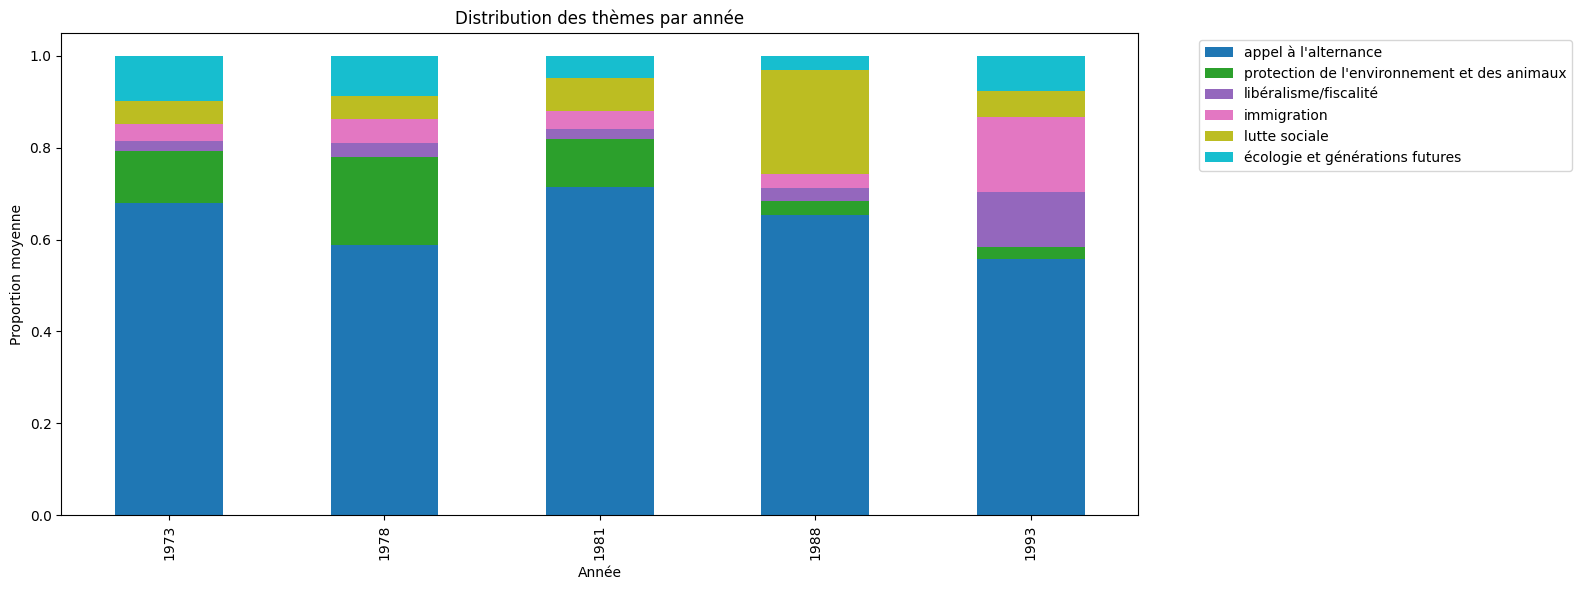

In [51]:
# topics / doc 
W_normalized = W / W.sum(axis=1, keepdims=True)

df['dominant_topic'] = np.argmax(W_normalized, axis=1)
df['dominant_label'] = df['dominant_topic'].map(topic_label)
df['topic_score']    = np.max(W_normalized, axis=1)

# topic distrib / year 
topic_cols = [f'topic_{i}' for i in range(N_TOPICS)]

# ajout colonnes
df = df.drop(columns=[col for col in df.columns if col.startswith('topic_')], errors='ignore')
W_df = pd.DataFrame(W_normalized, columns=topic_cols)
df = pd.concat([df.reset_index(drop=True), W_df], axis=1)

topic_by_year = df.groupby('annee')[topic_cols].mean()

topic_by_year.rename(
    columns={f'topic_{i}': topic_label[i] for i in range(N_TOPICS)}
).plot(
    kind='bar',
    stacked=True,
    figsize=(16, 6),
    colormap='tab10'
)
plt.title("Distribution des thèmes par année")
plt.ylabel("Proportion moyenne")
plt.xlabel("Année")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


In [53]:
#df.to_parquet("data/inter/df_nmf_5elec.parquet", engine="pyarrow", index=False, compression="snappy")

In [3]:
df = pd.read_parquet("data/inter/df_nmf_5elec.parquet")

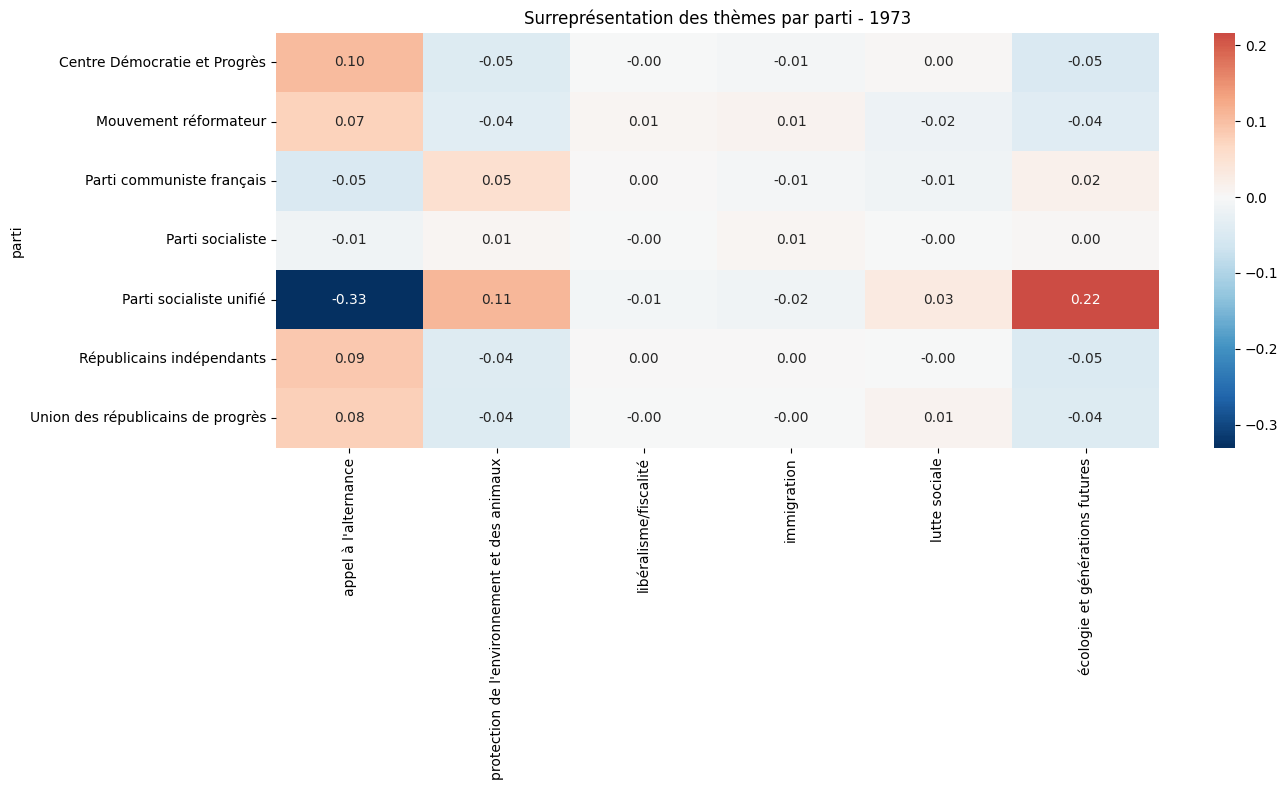

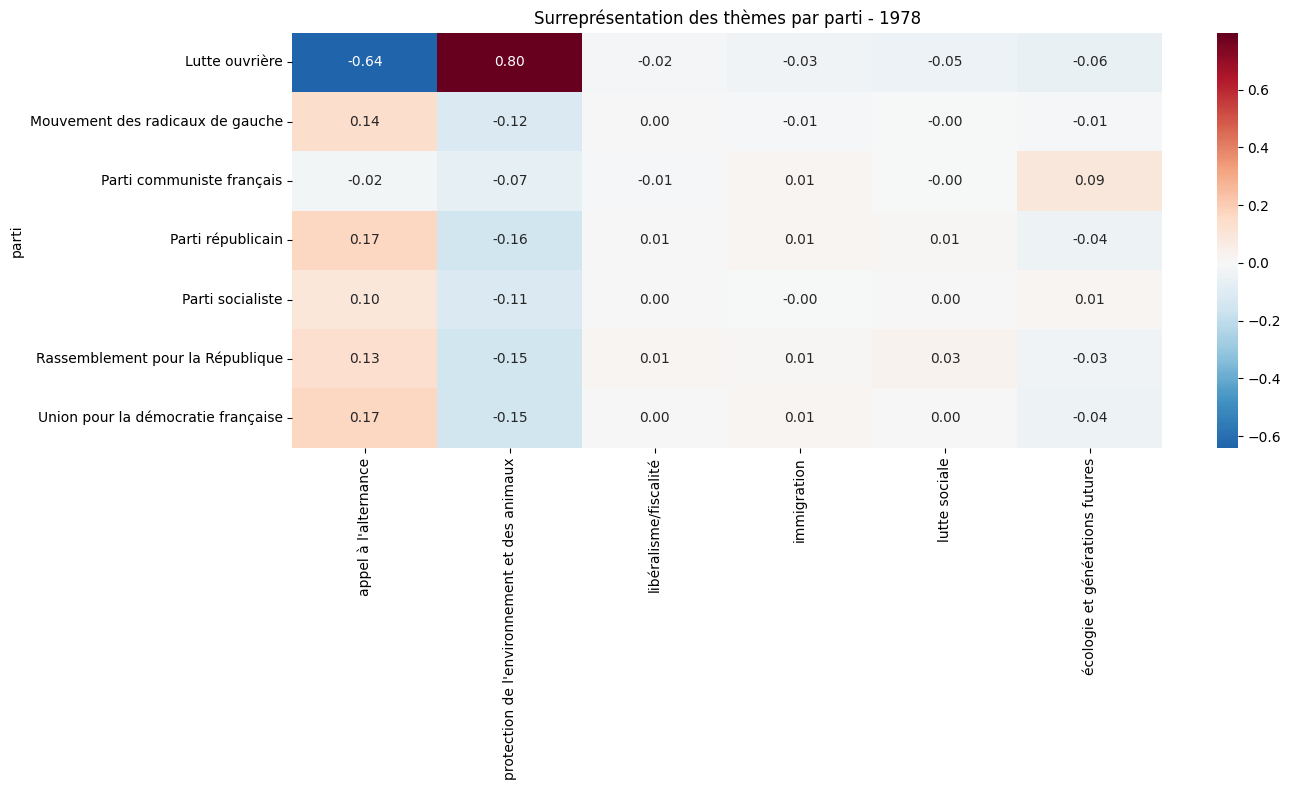

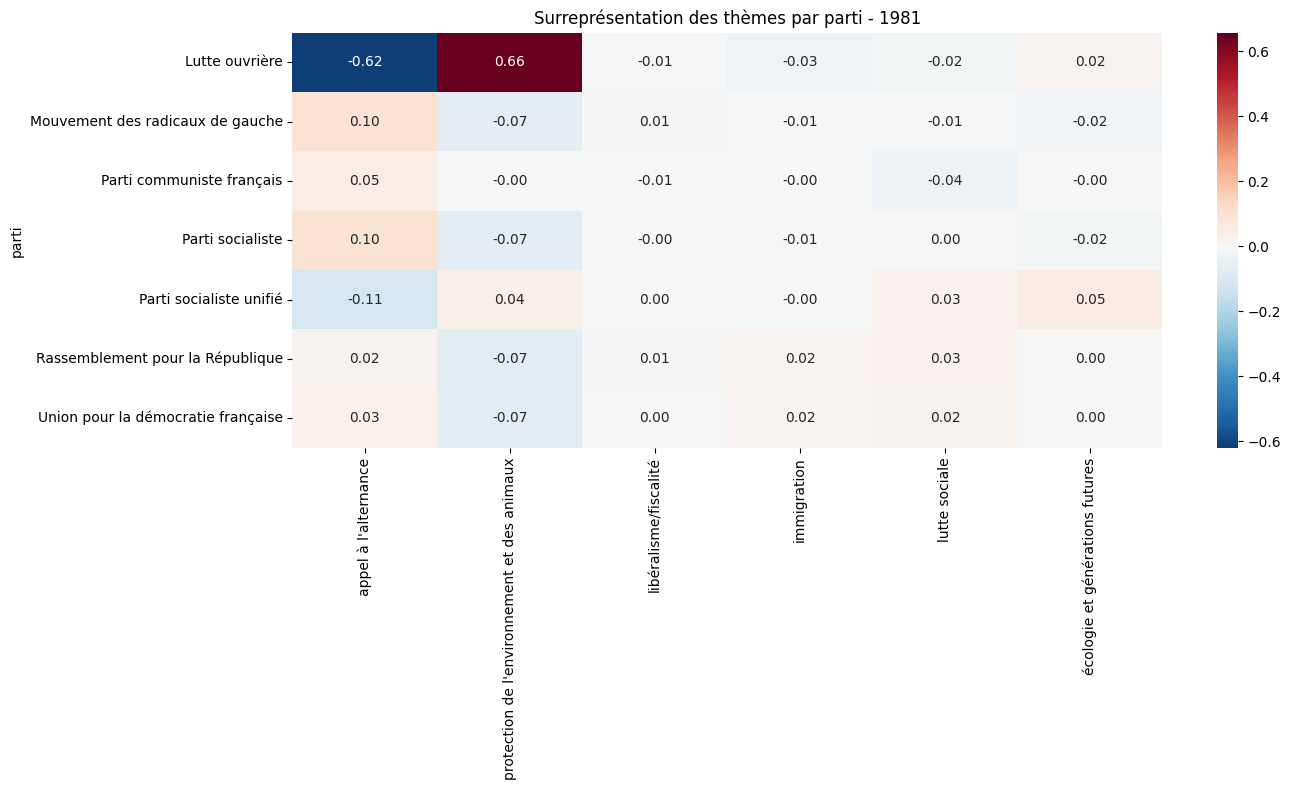

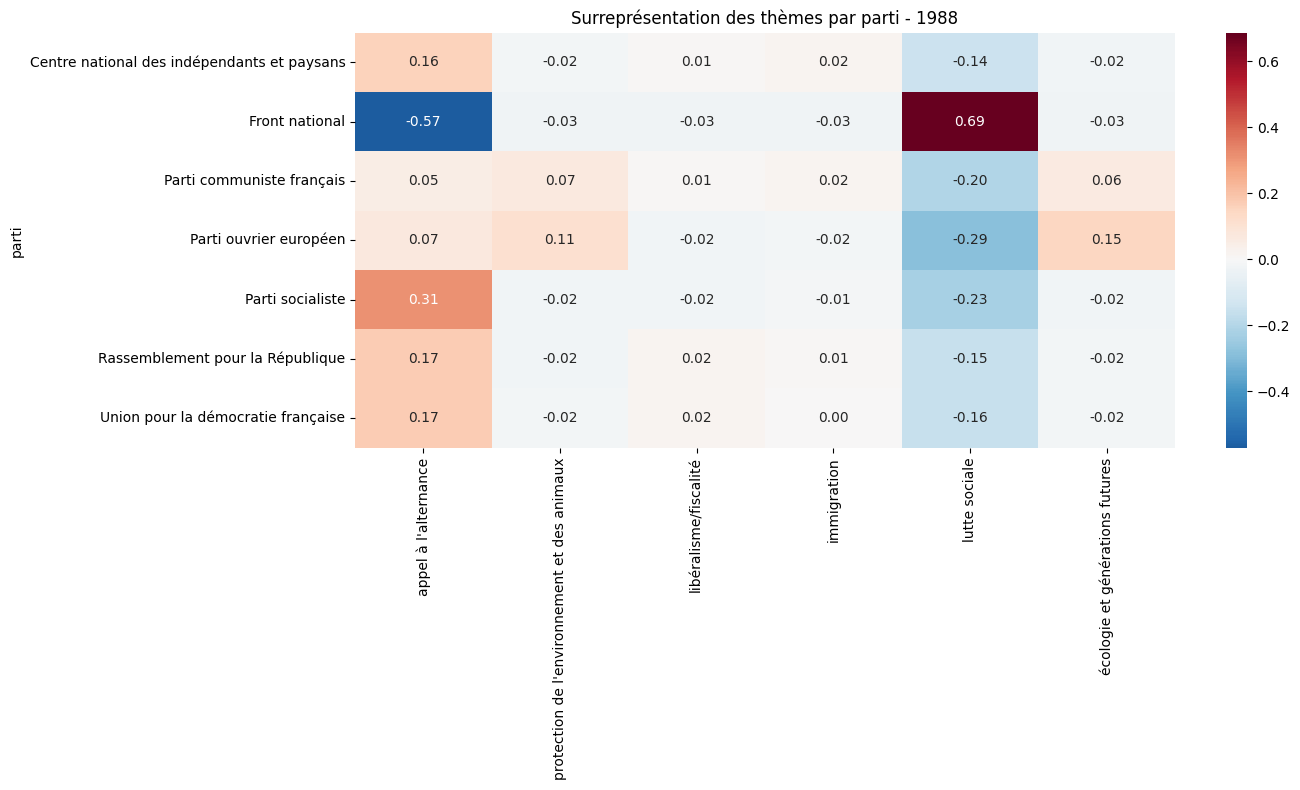

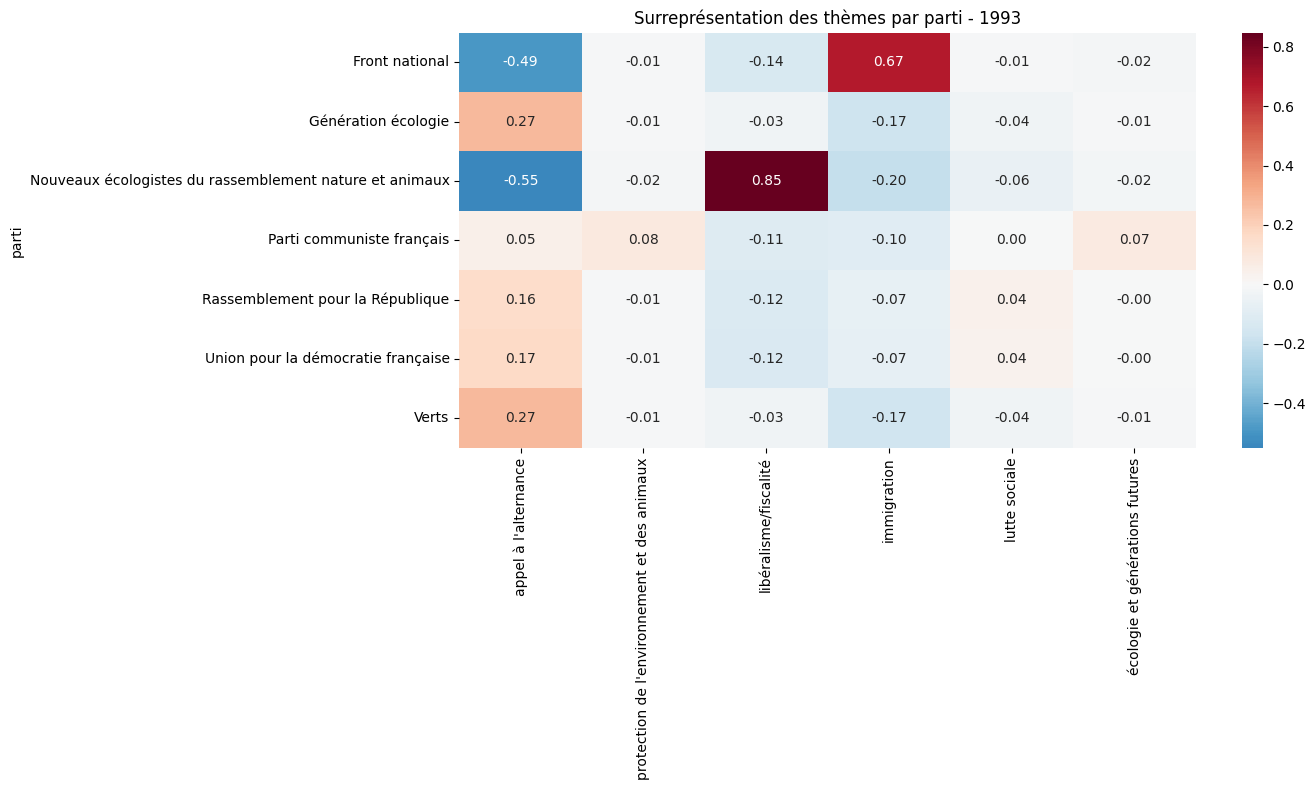

In [52]:
# créer un DataFrame explosé pour les partis
df_exploded = df.copy()
df_exploded['parti'] = df_exploded['titulaire-soutien'].str.split(';')
df_exploded = df_exploded.explode('parti')
df_exploded['parti'] = df_exploded['parti'].str.strip()
df_exploded = df_exploded[df_exploded['parti'].notna()]
df_exploded = df_exploded[df_exploded['parti'] != "non mentionné"]
df_exploded = df_exploded[df_exploded['parti'] != ""]

# boucle par année
for year, df_year in df_exploded.groupby('annee'):

    # compter les partis pour cette année et garder top nb_partis
    nb_partis = 7
    parti_counter = Counter(df_year['parti'])
    top_partis = [p for p, _ in parti_counter.most_common(nb_partis)]
    df_top = df_year[df_year['parti'].isin(top_partis)]

    # calcul surreprésentation
    global_mean = df_top[topic_cols].mean()
    topic_by_parti = df_top.groupby('parti')[topic_cols].mean()
    surreprésentation = topic_by_parti - global_mean

    # heatmap
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        surreprésentation.rename(
            columns={f'topic_{i}': topic_label[i] for i in range(N_TOPICS)}
        ),
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.2f'
    )
    plt.title(f"Surreprésentation des thèmes par parti - {year}")
    plt.tight_layout()
    plt.show()

#### (ii) Topic modeling with embeddings : Bertopic

In [22]:
# embeddings //
#les deux ci-dessous donnent quasi exactement les mêmes résultats
#embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embedding_model = SentenceTransformer("dangvantuan/sentence-camembert-base")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 846.29it/s, Materializing param=pooler.dense.weight]                               
CamembertModel LOAD REPORT from: dangvantuan/sentence-camembert-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [23]:
docs = df['text'].tolist()

We have to consider that our texts are too long for sentence-camenbert, and the encoder must be use with texts no longer than 512 tokens.

In [ ]:
#we divide our texts using our split_function to avoid too long texts (that would be over then 512 tokens-limit)
docs_segmented = []
doc_ids = []

for i, doc in enumerate(docs):
    segments = split_text_chunk(doc)
    docs_segmented.extend(segments)
    doc_ids.extend([i] * len(segments))

In [22]:
import torch
torch.set_num_threads(1)

num_cores  = 4
batch_size = 64
chunk_size = 512
chunks = [docs_segmented[i:i+chunk_size] for i in range(0, len(docs_segmented), chunk_size)]
num_chunks = len(chunks)
print(f"Nombre total de chunks : {num_chunks}")
print(f"Embeddings générés pour {len(docs_segmented)} segments")

Nombre total de chunks : 122
Embeddings générés pour 62309 segments


nouvel essai (reco Chat)

In [23]:

# 🔧 réglage CPU (important)
torch.set_num_threads(16)

start_total = time.time()

embeddings = embedding_model.encode(
    docs_segmented,
    batch_size=128,              # commence à 64 si tu veux être safe
    convert_to_numpy=True,
    show_progress_bar=True
)

total_time = time.time() - start_total

print(f"\n✅ Embeddings générés pour {len(docs_segmented)} segments")
print(f"Shape : {embeddings.shape}")
print(f"Temps total : {total_time/60:.2f} minutes")

Batches: 100%|██████████| 487/487 [16:14<00:00,  2.00s/it]



✅ Embeddings générés pour 62309 segments
Shape : (62309, 768)
Temps total : 16.31 minutes


ancien modèle 

In [24]:
import torch
torch.set_num_threads(1)

num_cores  = 4
batch_size = 32
chunk_size = 512

def encode_chunk(chunk, chunk_idx):
    start      = time.time()
    embeddings_old = embedding_model.encode(chunk, batch_size=batch_size, convert_to_numpy=True, show_progress_bar=True)
    elapsed    = time.time() - start
    print(f"✅ Chunk {chunk_idx+1}/{num_chunks} traité en {elapsed:.2f}s")
    return embeddings_old, elapsed

start_total_chunk = time.time()

results = Parallel(n_jobs=num_cores, prefer="processes")(
    delayed(encode_chunk)(chunk, idx) for idx, chunk in enumerate(chunks)
)

embeddings_old = np.vstack([res[0] for res in results])
total_time_chunk = time.time() - start_total_chunk

print(f"\n Embeddings générés pour {len(docs)} textes")
print(f"Shape : {embeddings_old.shape}")
print(f"Temps total : {total_time_chunk/60:.2f} minutes")

Batches: 100%|██████████| 16/16 [00:16<00:00,  1.01s/it]


✅ Chunk 1/122 traité en 16.21s


Batches:  88%|████████▊ | 14/16 [00:14<00:02,  1.05s/it]

✅ Chunk 2/122 traité en 16.45s


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

...

Batches:  19%|█▉        | 3/16 [00:03<00:13,  1.03s/it]

✅ Chunk 120/122 traité en 16.06s


Batches: 100%|██████████| 12/12 [00:11<00:00,  1.02it/s]


✅ Chunk 122/122 traité en 11.82s
✅ Chunk 121/122 traité en 16.60s

 Embeddings générés pour 21167 textes
Shape : (62309, 768)
Temps total : 10.92 minutes


Batches: 100%|██████████| 16/16 [00:16<00:00,  1.04s/it]


In [25]:
#nltk.download('stopwords')
STOPWORDS = stopwords.words('french')+stopwords.words('german')
STOPWORDS = list(set(STOPWORDS))

In [ ]:
# UMAP : to reduce the dimensions of the embedding

umap_model = umap.UMAP(
    n_neighbors=5,
    min_dist=0.0,
    n_components=5,
    random_state=42,
    n_jobs=8,
    verbose = True
)

# hdbscan : to get clusters
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=20,
    cluster_selection_epsilon=0.01,
    core_dist_n_jobs=8,
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=STOPWORDS,
    min_df=3
)

In [28]:
# --- BERTOPIC setup ---
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language='french',
    nr_topics=None,  # laisser BERTopic décider
    calculate_probabilities=True,
    verbose=True
)

# --- Fit sur les segments ---
topics_segments, probs_segments = topic_model.fit_transform(docs_segmented, embeddings=embeddings)

# --- Assigner topic dominant à chaque doc ---
df_segments = pd.DataFrame({
    "doc_id": doc_ids,  # correspond à chaque segment
    "topic": topics_segments,
    "score": probs_segments.max(axis=1)
})

# topic dominant par doc
df_doc = df_segments.groupby("doc_id").agg({
    "topic": lambda x: x.value_counts().index[0],  # topic le plus fréquent
    "score": "max"                                 # score max parmi les segments
}).reset_index()

# --- Réduction de topics sur les segments ---
topic_model.reduce_topics(docs_segmented, nr_topics=10)
topics_reduced, probs_reduced = topic_model.transform(docs_segmented, embeddings=embeddings)

# --- Assigner topics réduits à chaque doc ---
df_segments["topic_reduced"] = topics_reduced
df_segments["score_reduced"] = probs_reduced.max(axis=1)

# topic réduit dominant par doc
df_doc_reduced = df_segments.groupby("doc_id").agg({
    "topic_reduced": lambda x: x.value_counts().index[0],
    "score_reduced": "max"
}).reset_index()

# --- Fusion avec le dataset final ---
df = df.merge(df_doc_reduced, left_on="doc_id", right_on="doc_id", how="left")
df.rename(columns={
    "topic_reduced": "BERTopic_dominant",
    "score_reduced": "BERTopic_score"
}, inplace=True)

# --- Vérification finale ---
print(topic_model.get_topic_info())

2026-04-06 20:32:45,123 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-06 20:33:24,565 - BERTopic - Dimensionality - Completed ✓
2026-04-06 20:33:24,573 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-06 20:48:06,168 - BERTopic - Cluster - Completed ✓
2026-04-06 20:48:06,182 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-06 20:48:12,691 - BERTopic - Representation - Completed ✓
2026-04-06 20:48:18,269 - BERTopic - Topic reduction - Reducing number of topics
2026-04-06 20:48:18,308 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-06 20:48:26,097 - BERTopic - Representation - Completed ✓
2026-04-06 20:48:26,104 - BERTopic - Topic reduction - Reduced number of topics from 460 to 10
2026-04-06 20:48:26,533 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-04-06 20:48:26,796 - BERTopic - Dimensionality - Completed ✓
2026-04-06

KeyError: 'doc_id'

In [ ]:
topic_model.visualize_barchart(top_n_topics=10) 

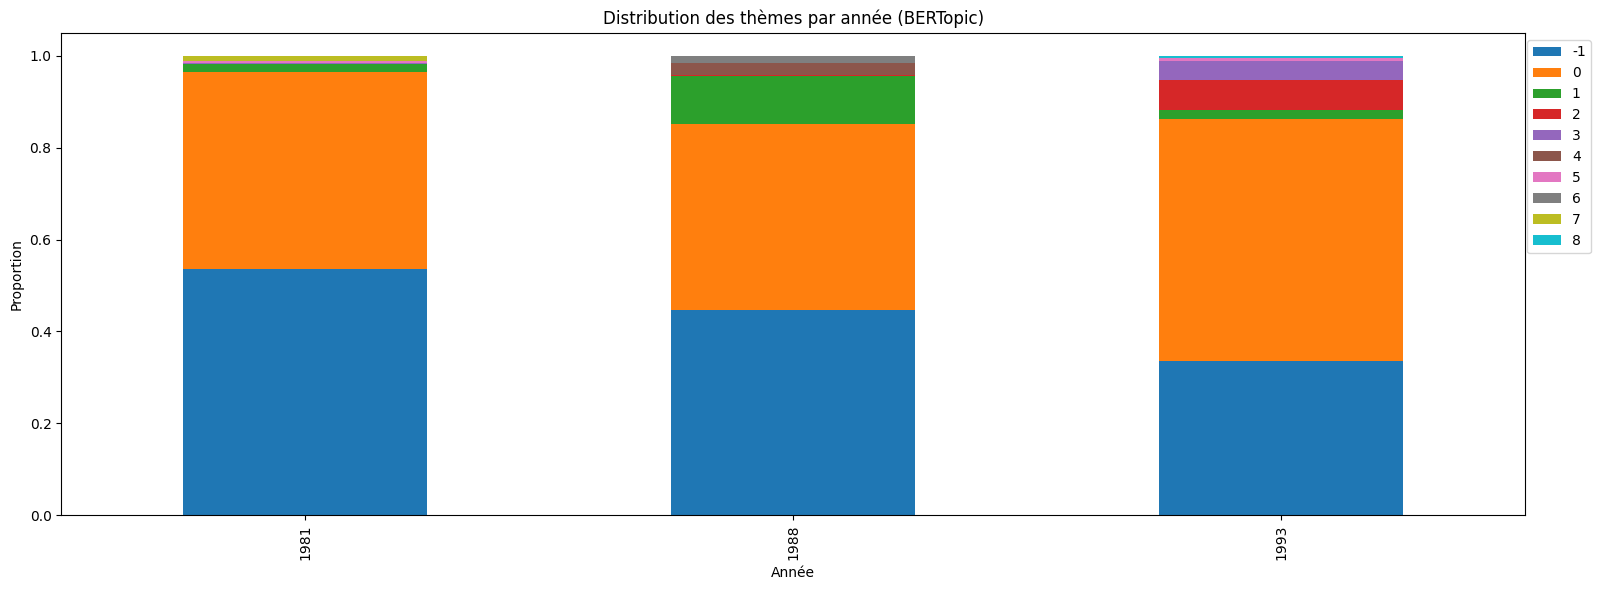

In [ ]:
#distrib topic par année
topic_info = topic_model.get_topic_info().set_index('Topic')['Name'].to_dict()

topic_by_year = df.groupby(['annee', 'BERTopic_dominant']).size().unstack(fill_value=0)
topic_by_year = topic_by_year.div(topic_by_year.sum(axis=1), axis=0)  # normalisation

topic_by_year.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 6),
    colormap='tab10'
)
plt.title("Distribution des thèmes par année (BERTopic)")
plt.ylabel("Proportion")
plt.xlabel("Année")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### Restes Caroline à insérer ? 

In [14]:
meta_et_texts_metier = meta_et_texts[meta_et_texts['titulaire-profession'] != 'non mentionné']
print(meta_et_texts.shape)
print(meta_et_texts_metier.shape)

(21167, 7)
(11702, 7)


Embedding : we transform texts into vectors of numbers ; to do so, we create chunks of texts that are transformed into number
Around 3'30

In [23]:
# put the texts together in chunks
chunks = [texts[i:i+chunk_size] for i in range(0, len(texts), chunk_size)]
num_chunks = len(chunks)

print(f"Nombre total de chunks : {num_chunks}")

# Function to encode chunk
def encode_chunk(chunk, chunk_idx):
    start = time.time()
    embeddings = model.encode(chunk, batch_size=batch_size,show_progress_bar=True, convert_to_numpy=True)
    end = time.time()
    elapsed = end - start
    print(f"✅ Chunk {chunk_idx+1}/{num_chunks} traité en {elapsed:.2f}s")
    return embeddings, elapsed


# Parallel encoding with timer
start_total = time.time()

results = Parallel(n_jobs=num_cores)(
    delayed(encode_chunk)(chunk, idx) for idx, chunk in enumerate(chunks)
)

# Séparer embeddings et temps par chunk
embeddings_list = [res[0] for res in results]
chunk_times = [res[1] for res in results]

# We put back together all the embeddings
embeddings = np.vstack(embeddings_list)
total_time = time.time() - start_total


# Some statistics on the embeddings
print(f"\nEmbeddings générés pour {len(texts)} textes")
print(f"Shape des embeddings : {embeddings.shape}")
print(f"Temps total écoulé : {total_time/60:.2f} minutes")
print(f"Temps moyen par chunk : {np.mean(chunk_times):.2f} secondes")
print(f"Temps estimé si encore {num_chunks} chunks : {np.mean(chunk_times)*(num_chunks-1)/60:.2f} minutes")

Nombre total de chunks : 47


Batches:  75%|███████▌  | 3/4 [00:11<00:03,  3.88s/it]

✅ Chunk 1/47 traité en 16.73s


Batches: 100%|██████████| 4/4 [00:15<00:00,  3.76s/it]


✅ Chunk 2/47 traité en 15.08s


...

Batches: 100%|██████████| 4/4 [00:13<00:00,  3.25s/it]


✅ Chunk 45/47 traité en 13.05s


Batches: 100%|██████████| 4/4 [00:10<00:00,  2.66s/it]


✅ Chunk 47/47 traité en 10.68s
✅ Chunk 46/47 traité en 15.97s

Embeddings générés pour 11702 textes
Shape des embeddings : (11702, 384)
Temps total écoulé : 3.27 minutes
Temps moyen par chunk : 14.21 secondes
Temps estimé si encore 47 chunks : 10.90 minutes


Batches: 100%|██████████| 4/4 [00:15<00:00,  3.98s/it]


## Classification par thème (suite ii bis BERT caroline)

Ci-dessous, on transforme notre embedding en vecteurs de bcp plus petite dimension (environ 20 sec avec ces paramètre d'UMAP)

In [32]:
umap_embeddings = umap.UMAP(
    n_neighbors=15, min_dist=0.3, n_components=5, random_state=42, verbose = True
).fit_transform(embeddings)
print(f"UMAP embeddings shape: {umap_embeddings.shape}")

UMAP(min_dist=0.3, n_components=5, n_jobs=1, random_state=42, verbose=True)
Sat Mar 28 16:17:56 2026 Construct fuzzy simplicial set
Sat Mar 28 16:17:56 2026 Finding Nearest Neighbors
Sat Mar 28 16:17:56 2026 Building RP forest with 10 trees
Sat Mar 28 16:17:56 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	 4  /  14
	Stopping threshold met -- exiting after 4 iterations
Sat Mar 28 16:17:58 2026 Finished Nearest Neighbor Search
Sat Mar 28 16:17:58 2026 Construct embedding


Epochs completed:   3%| ▎          6/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  12%| █▏         23/200 [00:01]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  92%| █████████▎ 185/200 [00:11]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:12]


Sat Mar 28 16:18:11 2026 Finished embedding
UMAP embeddings shape: (11702, 5)


DBScan ci-dessous va créer des clusters thématiques

In [34]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=100,
                            min_samples=10,  # moins strict sur la densité
                            cluster_selection_method='leaf')
#on ajoute à notre dataframe le thème abordé par le candidat
meta_et_texts_metier['theme_cluster'] = clusterer.fit_predict(umap_embeddings)
print(f"Clusters trouvés : {meta_et_texts_metier['theme_cluster'].nunique()} (le -1 correspond aux outliers)")


Clusters trouvés : 14 (le -1 correspond aux outliers)


On essaie de labelliser les thèmes automatiquement

In [36]:
#on reliste tous les mots éliminés
all_stopwords = stopwords_fr.union(top_20_words)

# Function to get the "op words" per cluster
def get_top_words_filtered(texts, n=10):
    # put together all words in the cluster
    all_words = " ".join(texts).lower().split()
    # Remove all the words from the stowords list
    all_words = [w for w in all_words if w not in all_stopwords]
    # counting
    return Counter(all_words).most_common(n)

# Go through all clusters
for cluster_id in sorted(meta_et_texts_metier['theme_cluster'].unique()):
    if cluster_id == -1:  # ignore outliers if needed
        continue
    texts = meta_et_texts_metier[meta_et_texts_metier['theme_cluster'] == cluster_id]['texte_clean']  # utiliser la colonne filtrée
    top_words = get_top_words_filtered(texts,15)
    print(f"Cluster {cluster_id}: {top_words}")

Cluster 0: [('suppléant', 2279), ('lutte', 1403), ('progrès', 1019), ('candidats', 898), ('vote', 888), ('etat', 768), ('voter', 762), ('avertissement', 756), ('ouvrier', 642), ('révolutionnaires', 640), ('tour', 638), ('ouvriere', 630), ('ouvrière', 525), ('e', 524), ('gouvernement', 516)]
Cluster 1: [('national', 1957), ('front', 1614), ('vote', 1289), ('nationale', 1241), ('avenir', 919), ('rpr', 917), ('udf', 916), ('force', 915), ('votez', 645), ('populaire', 617), ('contre', 614), ('suppression', 614), ('convictions', 614), ('députés', 613), ('ici', 613)]
Cluster 2: [('voter', 2114), ('mitterrand', 1844), ('petits', 1483), ('contre', 1482), ('marchais', 1449), ('droite', 1271), ('lutte', 1267), ('femmes', 1065), ('travailleuses', 1056), ('gouvernement', 894), ('candidats', 855), ('hommes', 850), ('politiques', 822), ('commerçants', 813), ('ouvriere', 714)]
Cluster 3: [('voter', 1339), ('mitterrand', 1168), ('contre', 938), ('petits', 937), ('marchais', 888), ('droite', 804), ('fe

## 2/ Croisement avec les professions des candidats


PENSER A FAIRE UN CHOIX DE TRAITEMENT POUR LES METIERS "NON MENTIONNES"

On a plus de 3000 professions différentes, pas vraiment d'organisation ou de nomenclature déjà déterminée ; on va donc également utiliser de l'embedding et du clustering pour attribuer aux candidats une catégorie plus vaste de métier

In [4]:
df_metier = df[df['titulaire-profession'] != "non mentionné"].copy()
df_metier.shape

(11702, 54)

In [5]:
#small cleaning for jobs
professions = df_metier['titulaire-profession'].dropna()
professions_clean = (
    professions
    .str.lower()
    .str.strip()
    # we delete the ";" that separates the different professions declared by the same candidate
    .str.replace(";", " ", regex=False) 

)
unique_professions = professions_clean.unique()

unique_professions = [clean_prof(p) for p in unique_professions]
len(unique_professions)

3383

In [22]:
#Job Embedding (15 sec with camenbert)
#model_professions = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
model_professions = SentenceTransformer("dangvantuan/sentence-camembert-base")
embeddings_professions = model_professions.encode(unique_professions,
                                                batch_size=256,
                                                show_progress_bar=True)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 903.35it/s, Materializing param=pooler.dense.weight]                               
CamembertModel LOAD REPORT from: dangvantuan/sentence-camembert-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 14/14 [00:10<00:00,  1.30it/s]


In [19]:
from sklearn.cluster import KMeans

n_clusters = 12
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

clusters = kmeans.fit_predict(embeddings_professions)
prof_cluster_df = pd.DataFrame({
    "profession": unique_professions,
    "cluster": clusters
})

In [23]:
clusterer_prof = hdbscan.HDBSCAN(
    min_cluster_size=10,
    metric='euclidean'  # ou mieux: cosine avec normalisation
)

clusters_dbscan = clusterer_prof.fit_predict(embeddings_professions)

prof_cluster_df_dbscan = pd.DataFrame({
    "profession": unique_professions,
    "cluster_dbscan": clusters_dbscan
})

In [24]:
cluster_map = dict(zip(prof_cluster_df_dbscan.profession, prof_cluster_df_dbscan.cluster_dbscan))

df_metier["profession_clean"] = (
    df_metier["titulaire-profession"]
    .str.lower()
    .str.strip()
)

df_metier["profession_cluster"] = (
    df_metier["profession_clean"]
    .map(cluster_map)
)

In [27]:
#Analyse des clusters pour k-means
for i in range(n_clusters):
    print("\nCluster", i)
    print(prof_cluster_df[prof_cluster_df.cluster == i].profession.tolist())


Cluster 0
['administrateur civil', 'secrétaire général entreprise', 'greffier en chef', 'cadre fonction publique territoriale', 'directeur maison de retraite', 'cadre fonction publique', 'secrétaire attachée', 'instituteur secrétaire mairie', 'président directeur général entreprise', 'administrateur centre dinformation du rock', 'directeur  développement', 'assistante parlementaire', 'secrétaire direction', 'directeur cabinet préfet', 'gérant réseau télématique du centre', 'secrétaire général', 'conseiller gestion et environnement', 'directeur bureau détudes environnement', 'ambassadeur', 'conseil entreprise directeur cabinet', 'ministère de lintérieur', 'chargée de mission sénat', 'directeur centre de tourisme', 'directeur conseiller institut de sondages', 'secrétaire mairie', 'secrétaire comptable', 'inspecteur finances directeur administration centrale', 'fonctionnaire territorial', 'directeur établissement public', 'directeur tourisme ville', 'directeur groupe communication intern

In [25]:
#analyse des clusters en dbscan
for cluster_id in sorted(prof_cluster_df_dbscan["cluster_dbscan"].unique()):
    print("\nCluster", cluster_id)
    print(
        prof_cluster_df_dbscan[prof_cluster_df_dbscan.cluster_dbscan == cluster_id]
        .profession
        .tolist()
    )


Cluster -1
['attaché administration universitaire', 'agent de maîtrise', 'technicienne cnrs', 'professeur sciences physiques', 'mission locale', 'employé douanes', 'assistant technique épuration des eaux', 'agent ratp', 'informaticienne', 'docteur-vétérinaire', 'administrateur civil', 'médecin anesthésiste', 'comptable responsable personnel', 'chargé de mission création dentreprises', 'expert-comptable', 'enseignant éducation physique et sportive', 'professeur droit social', 'responsable régional industrie pharmaceutique', 'technicien atelier', 'artisan commerçant', 'professeur histoire médiévale université', 'conseiller environnement', 'secrétaire général entreprise', 'employé banque', 'architecte dplg', 'instituteur', 'greffier en chef', 'éleveur bovins fromager responsable filière transformation des produits', 'education nationale', 'coordinatrice organisme de formation professionnnelle', 'technicien laboratoire', 'docteur expert matériel médical', 'professeur collège directeur ser

In [60]:
cluster_labels = {
0: "fct_publique_admin",
1: "commercant_cadre_commercial",
2: "medical",
3: "legal",
4: "chef_prive",
5: "education_nationale",
6: "armee_aeronautique",
7: "employes_divers",
8: "technicien",
9: "ingenieur",
10: "journaliste",
11: "agriculture"
}

On ajoute les catégories des métiers au dataframe de base

In [61]:
df_metier["profession_category"] = (
    df_metier["profession_cluster"]
    .map(cluster_labels)
)

### Analyse conjointe des sujets des professions de foi et des métiers

In [65]:
df_metier['dominant_label'].head()

2    appel à l'alternance
3    appel à l'alternance
4    appel à l'alternance
8             immigration
9    appel à l'alternance
Name: dominant_label, dtype: object

In [66]:
pd.crosstab(
    df_metier["profession_category"],
    df_metier["dominant_label"],
    normalize="index"
)

dominant_label,appel à l'alternance,immigration,libéralisme/fiscalité,lutte sociale,protection de l'environnement et des animaux,écologie et générations futures
profession_category,,,,,,
agriculture,0.727569,0.059543,0.004078,0.044861,0.137847,0.026101
armee_aeronautique,0.844660,0.048544,0.000000,0.077670,0.024272,0.004854
chef_prive,0.953704,0.027778,0.000000,0.006173,0.006173,0.006173
commercant_cadre_commercial,0.825321,0.052885,0.006410,0.020833,0.073718,0.020833
education_nationale,0.913363,0.014684,0.000000,0.008811,0.041116,0.022026
employes_divers,0.812652,0.043796,0.000000,0.051095,0.072993,0.019465
fct_publique_admin,0.785569,0.047764,0.007114,0.035569,0.094512,0.029472
ingenieur,0.855305,0.070740,0.006431,0.051447,0.000000,0.016077
journaliste,0.810811,0.097713,0.000000,0.064449,0.014553,0.012474


##### Visualisation

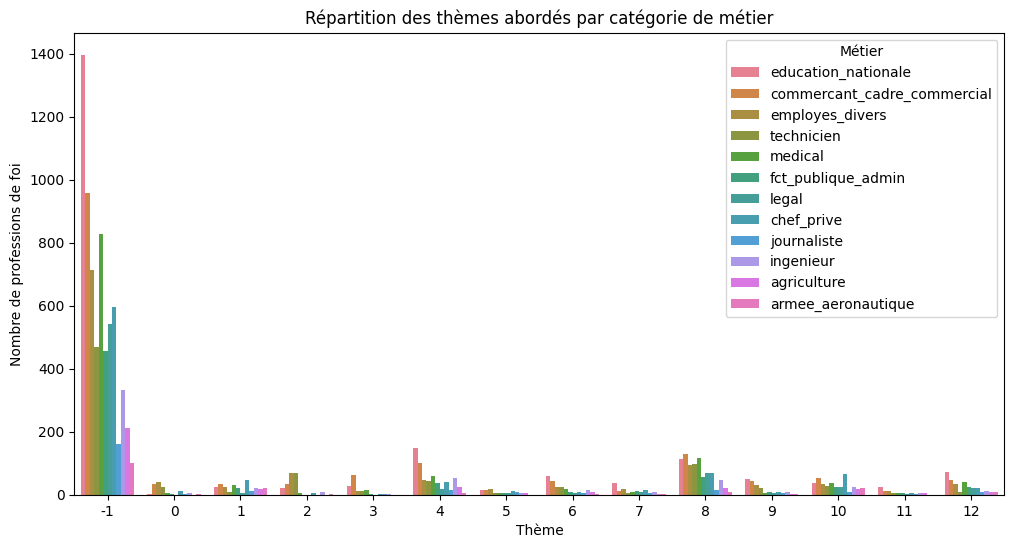

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='theme_cluster', hue='profession_category', data=df_metier)
plt.title("Répartition des thèmes abordés par catégorie de métier")
plt.xlabel("Thème")
plt.ylabel("Nombre de professions de foi")
plt.legend(title="Métier")
plt.show()

## Analyses statistiques diverses

In [ ]:
contingency_table = pd.crosstab(df_metier['profession_category'], df_metier['theme_cluster'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")

Chi2 = 1069.49, p-value = 0.0000
